In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("St_perform.csv")
df.head(20)

,ID,Age,Gender,StudyHours,Attendance,PreviousGPA,SleepHours,InternetHours,ParentEducation,PartTimeJob,ExtraActivities,FinalScore
0,1,18,Male,3,85,2.8,6,4,Bachelor,No,Yes,65
1,2,19,Female,5,92,3.4,7,3,Master,No,Yes,78
2,3,18,Female,2,70,2.5,5,6,HighSchool,Yes,No,55
3,4,20,Male,6,95,3.8,7,2,Master,No,Yes,88
4,5,19,Male,4,80,3.0,6,5,Bachelor,Yes,No,68
5,6,18,Female,7,98,3.9,8,2,PhD,No,Yes,92
6,7,21,Male,1,60,2.0,5,7,HighSchool,Yes,No,48
7,8,20,Female,5,90,3.5,7,3,Bachelor,No,Yes,82
8,9,19,Male,3,75,2.9,6,5,HighSchool,Yes,No,63
9,10,18,Female,6,93,3.7,7,2,Master,No,Yes,86


In [12]:
df.isnull().sum()

ID                 0
Age                0
Gender             0
StudyHours         0
Attendance         0
PreviousGPA        0
SleepHours         0
InternetHours      0
ParentEducation    0
PartTimeJob        0
ExtraActivities    0
FinalScore         0
dtype: int64

In [13]:
df.drop("ID", axis=1, inplace=True)
df.head(12)

,Age,Gender,StudyHours,Attendance,PreviousGPA,SleepHours,InternetHours,ParentEducation,PartTimeJob,ExtraActivities,FinalScore
0,18,Male,3,85,2.8,6,4,Bachelor,No,Yes,65
1,19,Female,5,92,3.4,7,3,Master,No,Yes,78
2,18,Female,2,70,2.5,5,6,HighSchool,Yes,No,55
3,20,Male,6,95,3.8,7,2,Master,No,Yes,88
4,19,Male,4,80,3.0,6,5,Bachelor,Yes,No,68
5,18,Female,7,98,3.9,8,2,PhD,No,Yes,92
6,21,Male,1,60,2.0,5,7,HighSchool,Yes,No,48
7,20,Female,5,90,3.5,7,3,Bachelor,No,Yes,82
8,19,Male,3,75,2.9,6,5,HighSchool,Yes,No,63
9,18,Female,6,93,3.7,7,2,Master,No,Yes,86


# Feature Engineering

In [15]:
df['StudyAttendance'] = df["Attendance"] * df["StudyHours"]
df.head()

,Age,Gender,StudyHours,Attendance,PreviousGPA,SleepHours,InternetHours,ParentEducation,PartTimeJob,ExtraActivities,FinalScore,StudyAttendance
0,18,Male,3,85,2.8,6,4,Bachelor,No,Yes,65,255
1,19,Female,5,92,3.4,7,3,Master,No,Yes,78,460
2,18,Female,2,70,2.5,5,6,HighSchool,Yes,No,55,140
3,20,Male,6,95,3.8,7,2,Master,No,Yes,88,570
4,19,Male,4,80,3.0,6,5,Bachelor,Yes,No,68,320


# EDA 

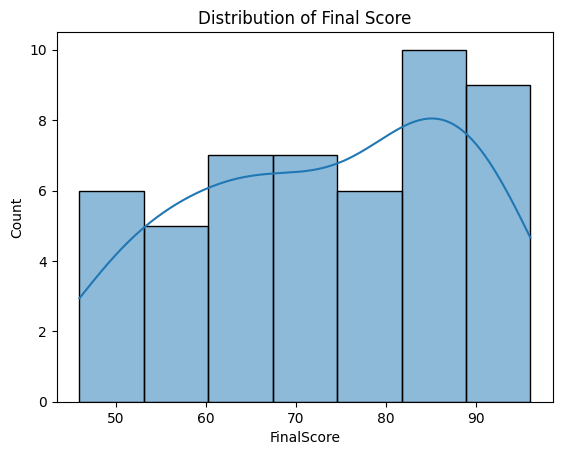

In [18]:
sns.histplot(df["FinalScore"], kde=True)
plt.title("Distribution of Final Score")
plt.show()

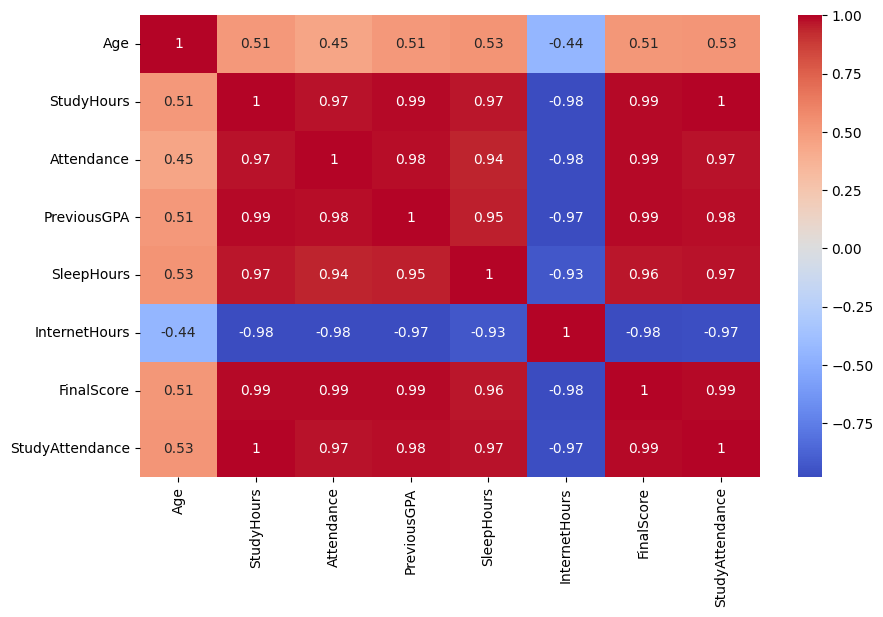

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

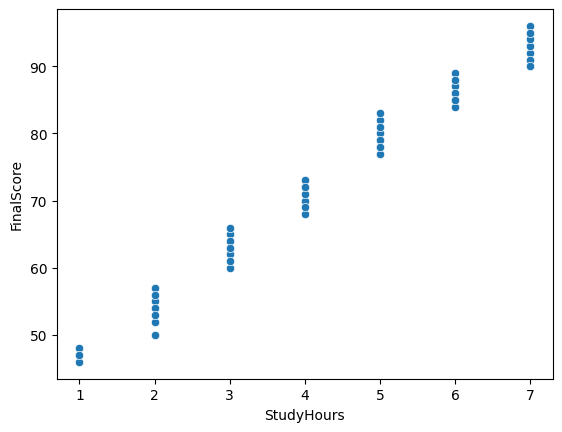

In [24]:
sns.scatterplot(x="StudyHours", y="FinalScore", data=df)
plt.show()

# Defining Features and Targets

In [25]:
X = df.drop("FinalScore", axis=1)
y = df["FinalScore"]

# Encoding and Scaling (By using Sklearn.preprocessing)

In [27]:
df.columns

Index(['Age', 'Gender', 'StudyHours', 'Attendance', 'PreviousGPA',
       'SleepHours', 'InternetHours', 'ParentEducation', 'PartTimeJob',
       'ExtraActivities', 'FinalScore', 'StudyAttendance'],
      dtype='object')

In [28]:
cat_cols = ['Gender','PartTimeJob','ExtraActivities','ParentEducation']
num_col = X.drop(columns=cat_cols).columns


Index(['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'SleepHours',
       'InternetHours', 'StudyAttendance'],
      dtype='object')

In [34]:
ppsr = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_col),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Train Test Split 

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying Algorithms/Models with Pipelines 

<h3>Linear Regression</h3>

In [38]:
lr_model = Pipeline([
    ("preprocessor", ppsr),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

<h3>Decision Tree</h3>

In [39]:
dt_model = Pipeline([
    ("preprocessor", ppsr),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

<h3>Random Forest</h3>

In [40]:
rf_model = Pipeline([
    ("preprocessor", ppsr),
    ("model", RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

<h3>SVM (Support Vector Machine)</h3>

In [41]:
svm_model = Pipeline([
    ("preprocessor", ppsr),
    ("model", SVR())
])

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# Evaluation Function and Application

In [42]:
def evaluate_model(name, y_test, y_pred):
    print(f"----- {name} -----")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print()

In [43]:
evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("SVM", y_test, svm_pred)

----- Linear Regression -----
MAE: 1.8679828261901803
MSE: 4.330977183846351
RMSE: 2.0810999937163883
R2 Score: 0.966272274870755

----- Decision Tree -----
MAE: 2.2
MSE: 7.4
RMSE: 2.7202941017470885
R2 Score: 0.942372089401137

----- Random Forest -----
MAE: 1.2130000000000003
MSE: 2.5770299999999984
RMSE: 1.6053130535817612
R2 Score: 0.9799312358850557

----- SVM -----
MAE: 3.2775774306341363
MSE: 42.293167279908204
RMSE: 6.503319712262977
R2 Score: 0.6706396131149583



# ML Visualization

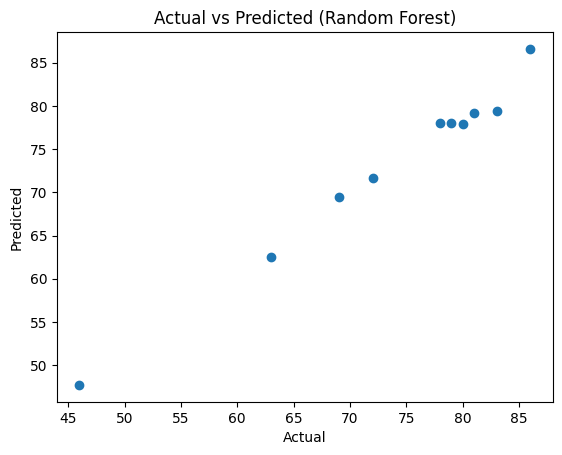

In [48]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

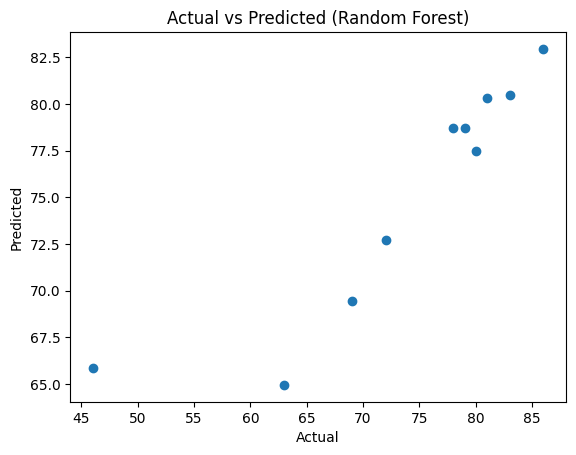

In [49]:
plt.scatter(y_test, svm_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

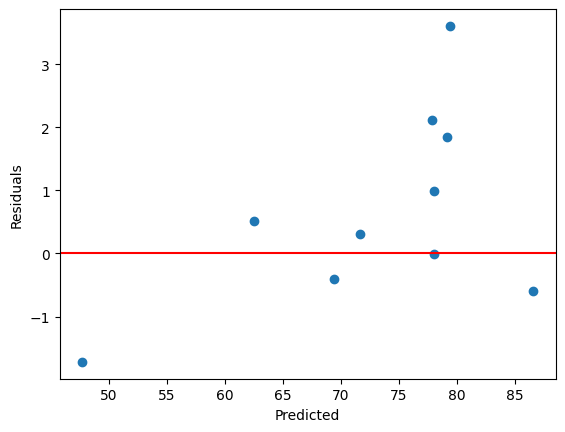

In [50]:
residuals = y_test - rf_pred

plt.scatter(rf_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

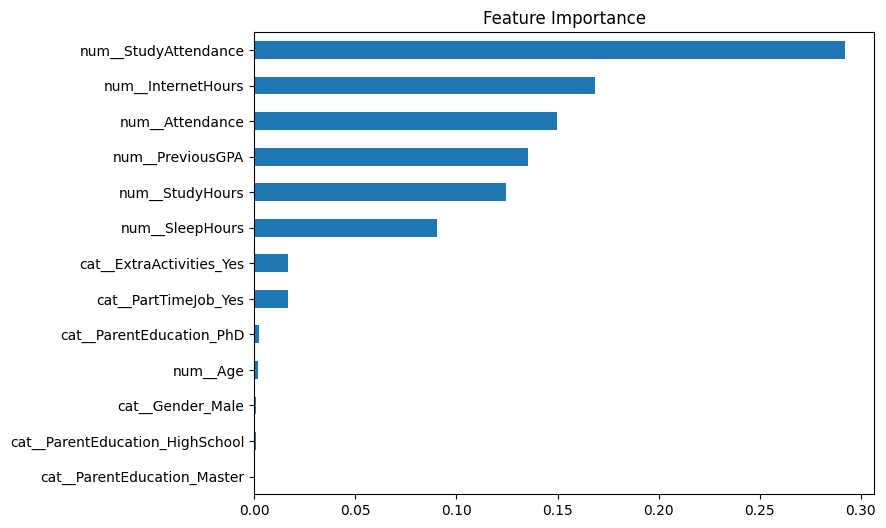

In [52]:
model = rf_model.named_steps["model"]
features = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = model.feature_importances_

feat_importance = pd.Series(importances, index=features)
feat_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

# PREDICTION

In [57]:
new_student = pd.DataFrame({
    "Age":[19],
    "Gender":["Male"],
    "StudyHours":[9],
    "Attendance":[90],
    "PreviousGPA":[3.5],
    "SleepHours":[10],
    "InternetHours":[15],
    "ParentEducation":["Master"],
    "PartTimeJob":["Yes"],
    "ExtraActivities":["Yes"],
    "StudyAttendance":[9*90]
})

prediction = rf_model.predict(new_student)
print("Predicted Final Score:", prediction[0])

Predicted Final Score: 83.24333333333335


In [58]:
new_student = pd.DataFrame({
    "Age":[19],
    "Gender":["Male"],
    "StudyHours":[9],
    "Attendance":[90],
    "PreviousGPA":[3.5],
    "SleepHours":[10],
    "InternetHours":[15],
    "ParentEducation":["Master"],
    "PartTimeJob":["Yes"],
    "ExtraActivities":["Yes"],
    "StudyAttendance":[9*90]
})

prediction = svm_model.predict(new_student)
print("Predicted Final Score:", prediction[0])

Predicted Final Score: 74.13702377864001


In [60]:
new_student = pd.DataFrame({
    "Age":[19],
    "Gender":["Male"],
    "StudyHours":[9],
    "Attendance":[90],
    "PreviousGPA":[3.5],
    "SleepHours":[10],
    "InternetHours":[15],
    "ParentEducation":["Master"],
    "PartTimeJob":["Yes"],
    "ExtraActivities":["Yes"],
    "StudyAttendance":[9*90]
})

prediction = lr_model.predict(new_student)
print("Predicted Final Score:", prediction[0])

Predicted Final Score: 114.77500972786768


In [61]:
new_student = pd.DataFrame({
    "Age":[19],
    "Gender":["Male"],
    "StudyHours":[9],
    "Attendance":[90],
    "PreviousGPA":[3.5],
    "SleepHours":[10],
    "InternetHours":[15],
    "ParentEducation":["Master"],
    "PartTimeJob":["Yes"],
    "ExtraActivities":["Yes"],
    "StudyAttendance":[9*90]
})

prediction = dt_model.predict(new_student)
print("Predicted Final Score:", prediction[0])

Predicted Final Score: 73.0
